# Local prototype: sales exploration, customer segments, product forecasts

A first pass at the three core analyses, run locally on **DuckDB** over the raw export. Its job is to validate the
analytical design (grain of the fact tables, revenue definition, segment scope, forecast setup) and surface data
issues **before** the same logic is built as the Databricks + dbt pipeline. The production versions will read from
the gold layer; this notebook is kept as the record of what the prototype found.

Aggregation is done in **SQL**, modeling and charts in **Python**.

| Part | Question | Method |
|---|---|---|
| 1 | Top categories by revenue, average order value (AOV) by territory, monthly trends | SQL aggregates, charts |
| 2 | Customer segments and strategies | SQL customer features, scikit-learn K-means with validation |
| 3 | Monthly forecasts for top-selling products | SQL product-month grid, change points, baselines vs ETS, rolling backtest |

**Definitions used throughout**

- **Revenue** = `SubTotal` (sum of line totals after discounts), **excluding tax and freight**. `TotalDue`
  = SubTotal + tax + freight is reconciled but not used as revenue.
- **Channel**: every order is either an **online** order from an individual customer or an **offline reseller
  (store)** order placed through a sales rep. The two never overlap in this data, and they behave very differently.
- **Analysis window**: 2011-05-31 to 2014-05-31. June 2014 is excluded as incomplete (shown in 1.2).

## 0. Setup and load

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.seasonal import STL

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config" / "aw_schema.json").exists())
sys.path.insert(0, str(ROOT / "src"))
from awlake.config import Config  # noqa: E402
from awlake.local_load import load_into_duckdb  # noqa: E402

RAW = ROOT / "data" / "raw"
FIG = ROOT / "reports" / "prototype" / "figures"
TAB = ROOT / "reports" / "prototype" / "tables"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

END = "2014-06-01"          # exclusive end of the analysis window (June 2014 is incomplete)
SEED = 42

CH_COLOR = {"Store (reseller)": "#2a78d6", "Online (individual)": "#eb6834"}
CAT_COLOR = {"Bikes": "#2a78d6", "Components": "#eb6834", "Clothing": "#1baf7a", "Accessories": "#eda100"}
INK, MUTED, GRID = "#2b2b2a", "#8a8984", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "xtick.color": "#52514e", "ytick.color": "#52514e", "lines.linewidth": 2,
    "legend.frameon": False, "font.size": 10,
})

def save(fig, name):
    fig.savefig(FIG / name, bbox_inches="tight")
    plt.show()

con = duckdb.connect()  # in-memory
TABLES = ["SalesOrderHeader", "SalesOrderDetail", "Customer", "SalesTerritory", "Product",
          "ProductSubcategory", "ProductCategory", "Store", "SpecialOffer", "ProductListPriceHistory"]
counts = load_into_duckdb(con, RAW, TABLES, Config(ROOT))
sql = lambda q: con.sql(q).df()
pd.Series(counts, name="rows").to_frame()

,rows
sales_order_header,31465
sales_order_detail,121317
customer,19820
sales_territory,10
product,504
product_subcategory,37
product_category,4
store,701
special_offer,16
product_list_price_history,395


The loader reads the raw export with the same schema and per-file fixes as the Databricks bronze layer (no header
row, column names from Microsoft's DDL) and fails if any table's row count differs from the profiled count.

### 0.1 Reconciliation

Before any analysis: do the order lines add up to the order header, and does TotalDue = SubTotal + tax + freight?

In [2]:
sql('''
WITH lines AS (SELECT sales_order_id, SUM(line_total) AS line_sum, COUNT(*) AS n_lines
               FROM sales_order_detail GROUP BY 1)
SELECT COUNT(*)                                                        AS orders,
       SUM(n_lines)                                                    AS order_lines,
       SUM(CASE WHEN ABS(h.sub_total - l.line_sum) > 0.01 THEN 1 ELSE 0 END)               AS subtotal_mismatches,
       SUM(CASE WHEN ABS(h.total_due - (h.sub_total + h.tax_amt + h.freight)) > 0.01 THEN 1 ELSE 0 END) AS totaldue_mismatches,
       ROUND(SUM(h.sub_total), 2)                                      AS revenue_subtotal,
       ROUND(SUM(h.total_due), 2)                                      AS total_due
FROM sales_order_header h JOIN lines l USING (sales_order_id)
''')

,orders,order_lines,subtotal_mismatches,totaldue_mismatches,revenue_subtotal,total_due
0,31465,121317.0,0.0,0.0,109846381.4,1.232168e+08


### 0.2 Analytical model (SQL views)

Two fact views at different grains, sharing the same dimensions:

- `fct_orders`: **one row per order**. Used for order counts and AOV. Computing AOV from lines joined to orders
  would count each order once per line.
- `fct_sales_lines`: **one row per order line**. Used for product and category revenue.

In [3]:
con.execute('''
CREATE OR REPLACE VIEW dim_product AS
SELECT p.product_id, p.name AS product, p.product_number, p.list_price, p.standard_cost,
       COALESCE(ps.name, 'Unassigned') AS subcategory, COALESCE(pc.name, 'Unassigned') AS category
FROM product p
LEFT JOIN product_subcategory ps ON p.product_subcategory_id = ps.product_subcategory_id
LEFT JOIN product_category pc    ON ps.product_category_id   = pc.product_category_id;

CREATE OR REPLACE VIEW fct_orders AS
SELECT h.sales_order_id, h.order_date, CAST(DATE_TRUNC('month', h.order_date) AS DATE) AS order_month,
       h.customer_id, c.store_id, t.name AS territory, t."group" AS territory_group,
       CASE WHEN h.online_order_flag THEN 'Online (individual)' ELSE 'Store (reseller)' END AS channel,
       h.sub_total AS revenue, h.tax_amt, h.freight, h.total_due
FROM sales_order_header h
JOIN customer c        USING (customer_id)
JOIN sales_territory t ON h.territory_id = t.territory_id;

CREATE OR REPLACE VIEW fct_sales_lines AS
SELECT d.sales_order_id, d.sales_order_detail_id, o.order_date, o.order_month, o.customer_id, o.channel,
       o.territory, d.product_id, dp.product, dp.subcategory, dp.category,
       d.order_qty, d.unit_price, d.unit_price_discount, d.special_offer_id, d.line_total AS revenue
FROM sales_order_detail d
JOIN fct_orders o  USING (sales_order_id)
JOIN dim_product dp USING (product_id);
''')
sql("SELECT channel, COUNT(*) AS orders, COUNT(DISTINCT customer_id) AS customers, "
    "ROUND(AVG(revenue), 2) AS aov, ROUND(SUM(revenue)) AS revenue FROM fct_orders GROUP BY 1")

,channel,orders,customers,aov,revenue
0,Online (individual),27659,18484,1061.45,29358677.0
1,Store (reseller),3806,635,21147.58,80487704.0


## 1. Sales exploration

### 1.1 Data coverage: why June 2014 is excluded

In [4]:
monthly_all = sql('''
SELECT order_month, channel, COUNT(*) AS orders, SUM(revenue) AS revenue
FROM fct_orders GROUP BY 1, 2 ORDER BY 1, 2
''')
cov = monthly_all.pivot(index="order_month", columns="channel", values=["orders", "revenue"]).fillna(0)
cov.tail(4).round(0)

orders                              revenue  \
channel     Online (individual) Store (reseller) Online (individual)   
order_month                                                            
2014-03-01               2128.0            271.0           1691179.0   
2014-04-01               2113.0              2.0           1795889.0   
2014-05-01               2232.0            179.0           1951196.0   
2014-06-01                939.0              0.0             49006.0   

                              
channel     Store (reseller)  
order_month                   
2014-03-01         5526352.0  
2014-04-01            1285.0  
2014-05-01         3415479.0  
2014-06-01               0.0

June 2014 has **no reseller orders** and online revenue of about 3% of May's. Reseller orders are booked in a batch
at month end, and June's batch is missing, so the month is a truncated extract rather than a real collapse in demand.
Every trend, ranking and forecast below stops at **May 2014**.

### 1.2 Top product categories by revenue

,category,revenue,share,units,store_share,products_sold
0,Bikes,"$94,651,173",86.2%,"90,268",70.1%,97
1,Components,"$11,802,593",10.7%,"49,044",100.0%,111
2,Clothing,"$2,104,265",1.9%,"73,251",84.6%,34
3,Accessories,"$1,239,344",1.1%,"60,221",46.1%,24


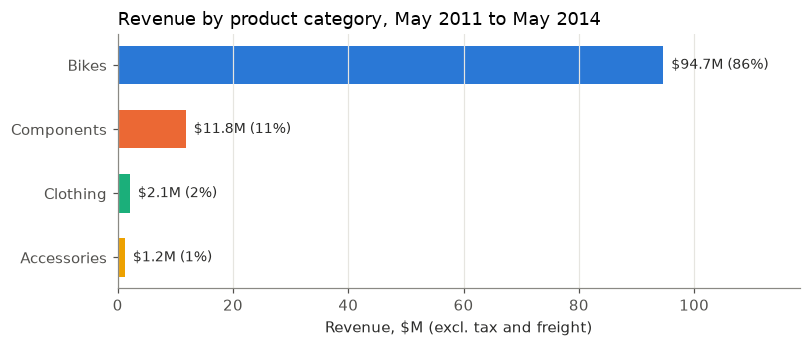

In [5]:
cat_rev = sql(f'''
SELECT category,
       SUM(revenue)                                         AS revenue,
       SUM(revenue) / SUM(SUM(revenue)) OVER ()             AS share,
       SUM(order_qty)                                       AS units,
       SUM(CASE WHEN channel = 'Store (reseller)' THEN revenue ELSE 0 END) / SUM(revenue) AS store_share,
       COUNT(DISTINCT product_id)                           AS products_sold
FROM fct_sales_lines WHERE order_date < '{END}'
GROUP BY 1 ORDER BY revenue DESC
''')
cat_rev.to_csv(TAB / "category_revenue.csv", index=False)
display(cat_rev.style.format({"revenue": "${:,.0f}", "share": "{:.1%}", "units": "{:,.0f}", "store_share": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(8, 3))
d = cat_rev.sort_values("revenue")
ax.barh(d["category"], d["revenue"] / 1e6, color=[CAT_COLOR[c] for c in d["category"]], height=0.6)
for y, (v, s) in enumerate(zip(d["revenue"] / 1e6, d["share"])):
    ax.text(v, y, f"  ${v:,.1f}M ({s:.0%})", va="center", color=INK, fontsize=9)
ax.set_xlabel("Revenue, $M (excl. tax and freight)")
ax.set_title("Revenue by product category, May 2011 to May 2014", loc="left")
ax.set_xlim(0, d["revenue"].max() / 1e6 * 1.25)
ax.grid(axis="y", visible=False)
save(fig, "category_revenue.png")

In [6]:
sub_rev = sql(f'''
SELECT category, subcategory, SUM(revenue) AS revenue, SUM(order_qty) AS units
FROM fct_sales_lines WHERE order_date < '{END}'
GROUP BY 1, 2 ORDER BY revenue DESC LIMIT 10
''')
sub_rev.style.format({"revenue": "${:,.0f}", "units": "{:,.0f}"})

,category,subcategory,revenue,units
0,Bikes,Road Bikes,"$43,909,438","47,196"
1,Bikes,Mountain Bikes,"$36,445,444","28,321"
2,Bikes,Touring Bikes,"$14,296,291","14,751"
3,Components,Mountain Frames,"$4,713,930","11,621"
4,Components,Road Frames,"$3,851,351","11,753"
5,Components,Touring Frames,"$1,642,328","3,725"
6,Clothing,Jerseys,"$744,733","22,565"
7,Components,Wheels,"$680,831","5,273"
8,Accessories,Helmets,"$474,881","19,279"
9,Clothing,Shorts,"$409,471","9,908"


### 1.3 Average order value by territory

In [7]:
terr = sql(f'''
SELECT territory, territory_group,
       COUNT(*)                                                       AS orders,
       AVG(revenue)                                                   AS aov_all,
       AVG(CASE WHEN channel = 'Store (reseller)'    THEN revenue END) AS aov_store,
       AVG(CASE WHEN channel = 'Online (individual)' THEN revenue END) AS aov_online,
       AVG(CASE WHEN channel = 'Store (reseller)' THEN 1.0 ELSE 0 END) AS store_order_share,
       MEDIAN(CASE WHEN channel = 'Online (individual)' THEN revenue END) AS median_online
FROM fct_orders WHERE order_date < '{END}'
GROUP BY 1, 2 ORDER BY aov_all DESC
''')
terr.to_csv(TAB / "territory_aov.csv", index=False)
display(terr.style.format({"aov_all": "${:,.0f}", "aov_store": "${:,.0f}", "aov_online": "${:,.0f}",
                           "median_online": "${:,.0f}", "store_order_share": "{:.1%}", "orders": "{:,}"}))
r = np.corrcoef(terr["store_order_share"], terr["aov_all"])[0, 1]
print(f"Correlation between a territory's share of store orders and its overall AOV: r = {r:.2f}")

,territory,territory_group,orders,aov_all,aov_store,aov_online,store_order_share,median_online
0,Central,North America,385,"$20,543","$21,027",$333,97.7%,$54
1,Northeast,North America,352,"$19,714","$20,271",$653,97.2%,$87
2,Southeast,North America,483,"$16,314","$16,775",$866,97.1%,$451
3,Canada,North America,"3,871","$4,223","$20,777",$619,17.9%,$70
4,Southwest,North America,"6,044","$4,000","$24,589","$1,079",12.4%,$608
5,Northwest,North America,"4,422","$3,635","$23,200",$937,12.1%,$148
6,France,Europe,"2,603","$2,785","$24,508","$1,093",7.2%,$776
7,United Kingdom,Europe,"3,137","$2,444","$22,761","$1,149",6.0%,$783
8,Germany,Europe,"2,554","$1,923","$14,540","$1,197",5.4%,$802
9,Australia,Pacific,"6,675","$1,595","$12,755","$1,382",1.9%,"$1,155"


Correlation between a territory's share of store orders and its overall AOV: r = 0.99


**The overall AOV ranking is driven by channel mix** (r = 0.99 between a territory's share of store orders and its AOV). Territories with mostly reseller orders (Central, Northeast,
Southeast) show $16k to $21k, and territories dominated by online orders (Australia, Germany) show under $2k.
That ranks **channel mix**, not customer value. The fair comparison is **within each channel**:

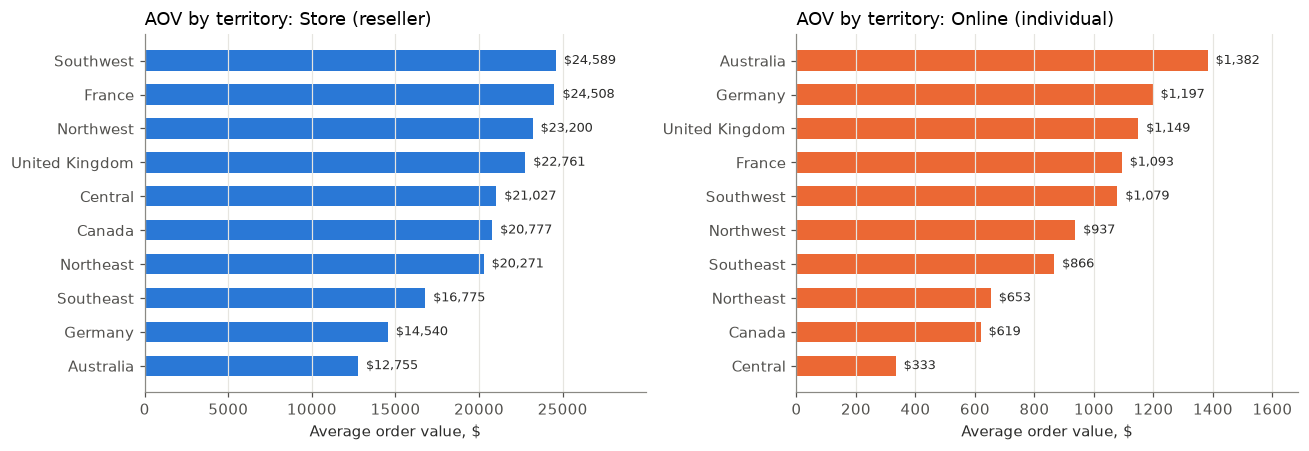

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, col, ch in [(axes[0], "aov_store", "Store (reseller)"), (axes[1], "aov_online", "Online (individual)")]:
    d = terr.sort_values(col)
    ax.barh(d["territory"], d[col], color=CH_COLOR[ch], height=0.6)
    for y, v in enumerate(d[col]):
        ax.text(v, y, f"  ${v:,.0f}", va="center", fontsize=8.5, color=INK)
    ax.set_xlim(0, d[col].max() * 1.22)
    ax.set_title(f"AOV by territory: {ch}", loc="left")
    ax.set_xlabel("Average order value, $")
    ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "territory_aov_by_channel.png")

**Within-channel reading**

- **Reseller orders**: Southwest, France and Northwest resellers place the largest orders (about $23k to $25k).
  Australia (about $12.8k) and Germany (about $14.5k) resellers order roughly half as much per order. These
  differences come from reseller size and buying cadence, not end-consumer value.
- **Online orders**: Australia and the European territories have the highest online AOV (about $1.1k to $1.4k),
  and Canada and the US Northeast and Central the lowest. The **median** online order shows why: about $1,155 in
  Australia vs about $70 in Canada. North American online customers buy far more low-priced accessories, while
  Australian and European online customers mostly buy bikes. Central and Northeast have very few online orders
  (most of their business is reseller), so their online figures are unreliable.
- Higher AOV describes **purchase behavior per order**. It does not establish higher customer lifetime value.

### 1.4 Monthly trends and seasonality

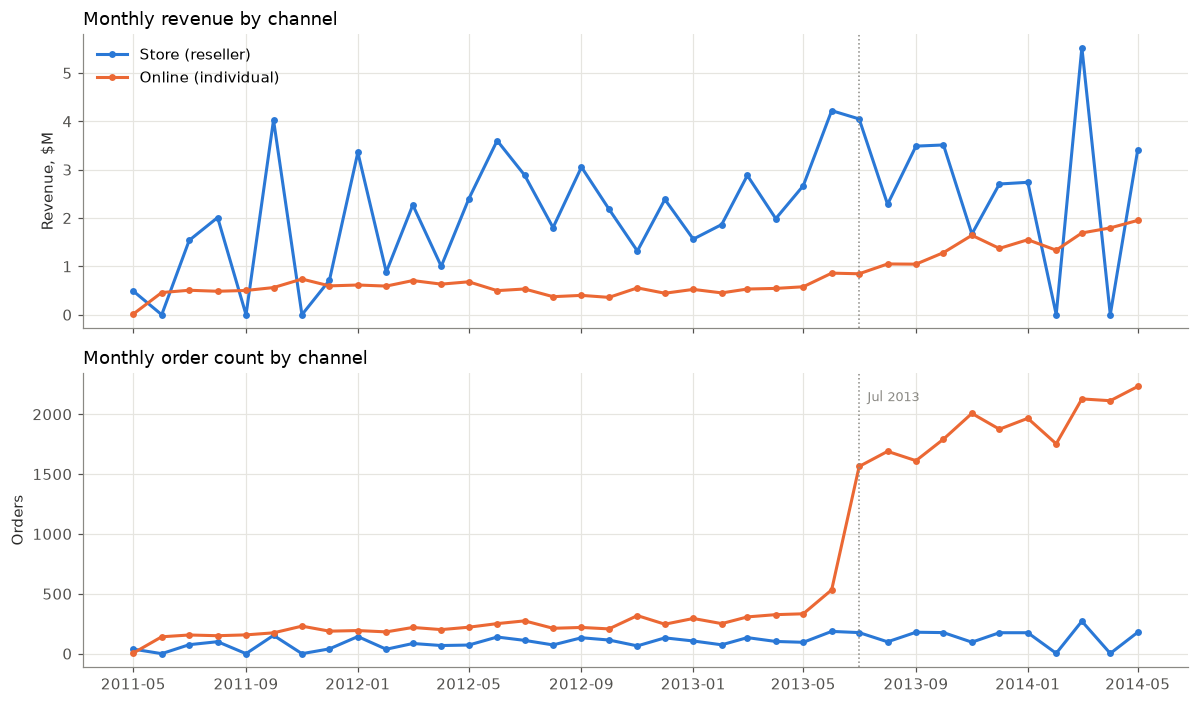

In [9]:
monthly = sql(f'''
SELECT order_month, channel, COUNT(*) AS orders, SUM(revenue) AS revenue
FROM fct_orders WHERE order_date < '{END}' GROUP BY 1, 2 ORDER BY 1
''')
mp = monthly.pivot(index="order_month", columns="channel", values=["orders", "revenue"]).fillna(0)
mp.index = pd.to_datetime(mp.index)
mp.to_csv(TAB / "monthly_by_channel.csv")

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
for ch, c in CH_COLOR.items():
    axes[0].plot(mp.index, mp[("revenue", ch)] / 1e6, "-o", ms=3.5, color=c, label=ch)
    axes[1].plot(mp.index, mp[("orders", ch)], "-o", ms=3.5, color=c, label=ch)
axes[0].set_ylabel("Revenue, $M"); axes[1].set_ylabel("Orders")
axes[0].set_title("Monthly revenue by channel", loc="left"); axes[1].set_title("Monthly order count by channel", loc="left")
for ax in axes:
    ax.axvline(pd.Timestamp("2013-07-01"), color=MUTED, linestyle=":", linewidth=1)
axes[1].text(pd.Timestamp("2013-07-10"), axes[1].get_ylim()[1] * 0.9, "Jul 2013", color=MUTED, fontsize=8.5)
axes[0].legend(loc="upper left")
fig.tight_layout()
save(fig, "monthly_trends.png")

In [10]:
yearly = sql(f'''
SELECT YEAR(order_date) AS year, channel, COUNT(*) AS orders, SUM(revenue) AS revenue,
       COUNT(DISTINCT order_month) AS months
FROM fct_orders WHERE order_date < '{END}' GROUP BY 1, 2 ORDER BY 1, 2
''')
display(yearly.style.format({"revenue": "${:,.0f}", "orders": "{:,}"}))

# Store channel: month-of-year pattern using the two complete calendar years
store_moy = sql('''
SELECT MONTH(order_date) AS month, AVG(m_rev) AS avg_store_revenue
FROM (SELECT order_month, MIN(order_date) AS order_date, SUM(revenue) AS m_rev
      FROM fct_orders WHERE channel = 'Store (reseller)' AND YEAR(order_date) IN (2012, 2013) GROUP BY 1)
GROUP BY 1 ORDER BY 1
''')
store_moy["index_vs_mean"] = store_moy["avg_store_revenue"] / store_moy["avg_store_revenue"].mean()
store_moy.style.format({"avg_store_revenue": "${:,.0f}", "index_vs_mean": "{:.2f}"})

,year,channel,orders,revenue,months
0,2011,Online (individual),"1,201","$3,863,120",8
1,2011,Store (reseller),406,"$8,778,552",5
2,2012,Online (individual),"2,743","$6,390,600",12
3,2012,Store (reseller),"1,172","$27,133,701",12
4,2013,Online (individual),"12,584","$10,732,127",12
5,2013,Store (reseller),"1,598","$32,890,352",12
6,2014,Online (individual),"10,192","$8,323,824",5
7,2014,Store (reseller),630,"$11,685,099",5


,month,avg_store_revenue,index_vs_mean
0,1,"$2,460,012",0.98
1,2,"$1,374,089",0.55
2,3,"$2,574,935",1.03
3,4,"$1,494,838",0.60
4,5,"$2,530,557",1.01
5,6,"$3,911,059",1.56
6,7,"$3,467,287",1.39
7,8,"$2,043,105",0.82
8,9,"$3,270,351",1.31
9,10,"$2,848,217",1.14


In [11]:
launch = sql(f'''
SELECT category,
       SUM(CASE WHEN order_date <  '2013-07-01' THEN order_qty ELSE 0 END) AS online_units_before_jul2013,
       SUM(CASE WHEN order_date >= '2013-07-01' THEN order_qty ELSE 0 END) AS online_units_from_jul2013,
       MIN(order_date)                                                       AS first_online_sale,
       COUNT(DISTINCT product_id)                                            AS products
FROM fct_sales_lines WHERE channel = 'Online (individual)' AND order_date < '{END}'
GROUP BY 1 ORDER BY 2 DESC
''')
launch

,category,online_units_before_jul2013,online_units_from_jul2013,first_online_sale,products
0,Bikes,5953.0,9252.0,2011-05-31,88
1,Accessories,800.0,33581.0,2013-05-30,22
2,Clothing,196.0,8486.0,2013-05-30,20


**What the trend charts show**

- **Online orders tripled in July 2013 (533 to 1,564), while online revenue was flat that month.** The table above shows why: before mid-2013 the online channel sold
  almost nothing but bikes. In mid-2013 accessories and clothing were added online. Order counts jumped because
  of cheap add-on items, so online AOV fell even as volume rose. This is a **catalog change**, not seasonal demand.
- **Reseller revenue swings month to month**, and some months have **no** reseller orders at all (for example
  Feb and Apr 2014), because resellers order in batches. The month-of-year index above
  reflects that ordering cadence more than consumer seasonality. With only two complete calendar years, any seasonal
  pattern is weak evidence.
- **2013 is the largest year in both channels**: reseller revenue grew about 21% over 2012 ($27.1M to $32.9M)
  and online revenue about 68% ($6.4M to $10.7M) on 4.6 times as many orders. 2014 covers only five months.
- In the two complete years, reseller revenue peaks in **June and July** (index 1.56 and 1.39) and is lowest in
  **February, April and November** (about 0.55 to 0.60). Plausibly pre-season stocking for summer cycling, but
  two years is thin evidence for seasonality.

## 2. Customer segmentation

**Scope decision.** Reseller (store) customers and individual (online) customers are separate populations: 635
stores average about $21k per order and 18,484 individuals about $1k. Clustering them together would just split
stores from individuals, which we already know. So **individuals are clustered** (2.1 to 2.5) and **stores are
profiled separately** (2.6).

### 2.1 Customer features (SQL)

In [12]:
feat = sql(f'''
WITH o AS (
  SELECT customer_id, sales_order_id, order_date, revenue FROM fct_orders
  WHERE channel = 'Online (individual)' AND order_date < '{END}'),
l AS (
  SELECT customer_id,
         SUM(order_qty)                                                         AS units,
         COUNT(DISTINCT category)                                               AS n_categories,
         SUM(CASE WHEN category = 'Bikes' THEN revenue ELSE 0 END) / SUM(revenue) AS bike_share
  FROM fct_sales_lines WHERE channel = 'Online (individual)' AND order_date < '{END}' GROUP BY 1)
SELECT o.customer_id,
       SUM(o.revenue)                                         AS total_revenue,
       COUNT(*)                                               AS n_orders,
       AVG(o.revenue)                                         AS aov,
       MAX(l.units) * 1.0 / COUNT(*)                          AS units_per_order,
       DATE_DIFF('day', MAX(o.order_date), DATE '{END}')      AS recency_days,
       DATE_DIFF('day', MIN(o.order_date), DATE '{END}')      AS tenure_days,
       MAX(l.n_categories)                                    AS n_categories,
       MAX(l.bike_share)                                      AS bike_share,
       MIN(o.order_date) < DATE '2013-06-01'                  AS first_order_before_jun2013
FROM o JOIN l USING (customer_id)
GROUP BY o.customer_id
''').set_index("customer_id")
feat.to_csv(TAB / "customer_features_individuals.csv")
feat.drop(columns="first_order_before_jun2013").describe(percentiles=[.25, .5, .75, .95]).T.round(2)

,count,mean,std,min,25%,50%,75%,95%,max
total_revenue,17939.0,1633.85,2139.79,2.29,51.92,548.98,2639.08,6029.57,13295.38
n_orders,17939.0,1.49,1.05,1.00,1.00,1.00,2.00,3.00,26.00
aov,17939.0,938.02,1045.47,2.29,40.89,548.98,1878.80,2951.65,3578.27
units_per_order,17939.0,2.23,0.92,1.00,1.50,2.00,3.00,4.00,8.00
recency_days,17939.0,168.48,143.72,1.00,66.00,147.00,240.00,335.10,1097.00
tenure_days,17939.0,327.84,275.04,1.00,123.00,248.00,458.00,929.00,1097.00
n_categories,17939.0,1.69,0.66,1.00,1.00,2.00,2.00,3.00,3.00
bike_share,17939.0,0.50,0.49,0.00,0.00,0.89,0.99,1.00,1.00


Recency and tenure are measured in days to the end of the analysis window (2014-06-01). The distributions are
heavily right-skewed: most customers ordered once or twice, and revenue spans single-item accessory buyers
to multi-bike buyers. **Skewed money and count features are log-transformed before scaling**, so a few large
customers do not dominate the distances.

### 2.2 Choosing the number of clusters

In [13]:
FEATURES = ["total_revenue", "n_orders", "aov", "units_per_order", "recency_days", "n_categories", "bike_share"]
LOG_COLS = ["total_revenue", "n_orders", "aov", "units_per_order"]

def log_some(X, cols=None):
    X = X.copy()
    for c in (cols or LOG_COLS):
        if c in X.columns:
            X[c] = np.log1p(X[c])
    return X

def make_pipe(k, seed=SEED, cols=FEATURES):
    return make_pipeline(FunctionTransformer(log_some), StandardScaler(),
                         KMeans(n_clusters=k, n_init=10, random_state=seed))

X = feat[FEATURES]
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X), size=min(6000, len(X)), replace=False)   # silhouette is O(n^2); sample it

rows = []
for k in range(2, 9):
    pipe = make_pipe(k).fit(X)
    Z = pipe[:-1].transform(X)
    lab = pipe[-1].labels_
    # stability: agreement of labels across 5 other random initializations
    aris = [adjusted_rand_score(lab, make_pipe(k, seed=s).fit(X)[-1].labels_) for s in range(1, 6)]
    rows.append({"k": k, "inertia": pipe[-1].inertia_,
                 "silhouette": silhouette_score(Z[sample_idx], lab[sample_idx]),
                 "davies_bouldin": davies_bouldin_score(Z, lab), "calinski_harabasz": calinski_harabasz_score(Z, lab),
                 "stability_ari": np.mean(aris), "min_cluster_share": np.bincount(lab).min() / len(lab)})
kq = pd.DataFrame(rows)
kq.to_csv(TAB / "cluster_k_selection.csv", index=False)
kq.round(3)

,k,inertia,silhouette,davies_bouldin,calinski_harabasz,stability_ari,min_cluster_share
0,2,68936.368,0.434,0.988,14736.652,1.000,0.489
1,3,57208.731,0.436,1.129,10716.739,0.981,0.081
2,4,47868.831,0.383,1.021,9704.466,0.959,0.031
3,5,41002.437,0.303,1.266,9247.551,0.965,0.031
4,6,36183.246,0.298,1.213,8860.601,0.785,0.028
5,7,30466.919,0.341,1.074,9329.477,0.878,0.022
6,8,27896.326,0.346,1.060,8969.130,0.811,0.022


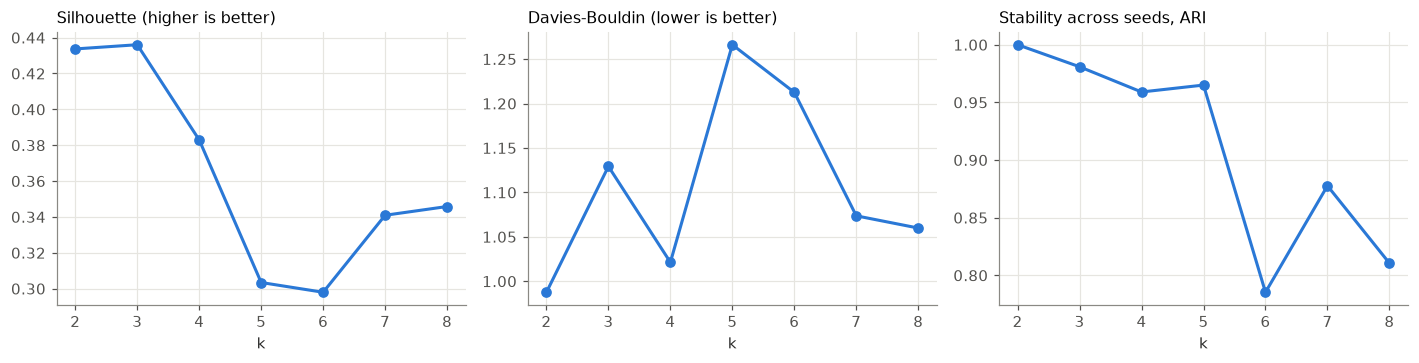

Chosen k = 3


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col, label in [(axes[0], "silhouette", "Silhouette (higher is better)"),
                       (axes[1], "davies_bouldin", "Davies-Bouldin (lower is better)"),
                       (axes[2], "stability_ari", "Stability across seeds, ARI")]:
    ax.plot(kq["k"], kq[col], "-o", color="#2a78d6", ms=6)
    ax.set_title(label, loc="left", fontsize=10.5); ax.set_xlabel("k")
fig.tight_layout()
save(fig, "cluster_k_selection.png")

# Rule: among k in 3..6 with stability ARI >= 0.9 and no cluster under 3% of customers,
# take the best silhouette. k=2 is excluded as too coarse to act on.
ok = kq[(kq.k.between(3, 6)) & (kq.stability_ari >= 0.9) & (kq.min_cluster_share >= 0.03)]
K = int((ok if len(ok) else kq[kq.k.between(3, 6)]).sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Chosen k =", K)

### 2.3 Feature-redundancy check

`total_revenue = n_orders × aov` exactly, so including all three counts the same information twice. The check:
refit **without `total_revenue`** and measure agreement with the full model (adjusted Rand index, ARI: 1 means
identical assignment, 0 means chance). High agreement means the redundancy does not drive the segments.

In [15]:
final = make_pipe(K).fit(X)
labels = final[-1].labels_
reduced_feats = [f for f in FEATURES if f != "total_revenue"]
red = make_pipeline(FunctionTransformer(log_some), StandardScaler(),
                    KMeans(n_clusters=K, n_init=10, random_state=SEED)).fit(feat[reduced_feats])
no_cat = [f for f in FEATURES if f not in ("n_categories", "bike_share")]
red2 = make_pipeline(FunctionTransformer(log_some), StandardScaler(),
                     KMeans(n_clusters=K, n_init=10, random_state=SEED)).fit(feat[no_cat])
pd.DataFrame({"variant": ["drop total_revenue", "drop product-mix features (n_categories, bike_share)"],
              "ARI vs full model": [adjusted_rand_score(labels, red[-1].labels_),
                                    adjusted_rand_score(labels, red2[-1].labels_)]}).round(3)

,variant,ARI vs full model
0,drop total_revenue,0.999
1,"drop product-mix features (n_categories, bike_...",0.859


### 2.4 Segment profiles in business units

In [16]:
prof = feat.assign(cluster=labels).groupby("cluster").agg(
    customers=("n_orders", "size"), revenue=("total_revenue", "sum"),
    median_revenue=("total_revenue", "median"), mean_orders=("n_orders", "mean"),
    median_aov=("aov", "median"), median_units_per_order=("units_per_order", "median"),
    median_recency_days=("recency_days", "median"), median_tenure_days=("tenure_days", "median"),
    mean_categories=("n_categories", "mean"), mean_bike_share=("bike_share", "mean"),
    first_order_before_jun2013=("first_order_before_jun2013", "mean"))
prof["customer_share"] = prof["customers"] / prof["customers"].sum()
prof["revenue_share"] = prof["revenue"] / prof["revenue"].sum()
prof = prof.sort_values("revenue", ascending=False)

# Names are assigned by rule from each cluster's profile (not by cluster number), so they stay correct if
# K-means numbers the clusters differently on another machine.
def seg_name(r):
    if r.mean_bike_share < 0.5:
        return "Accessory & clothing buyers"
    return "Bike + gear buyers" if r.mean_categories >= 1.5 else "Bike-only buyers"
prof.insert(0, "segment", [seg_name(r) for r in prof.itertuples()])
if K != 3 or prof["segment"].nunique() != len(prof):
    prof["segment"] = [f"{n} ({c})" for n, c in zip(prof["segment"], prof.index)]
prof.to_csv(TAB / "cluster_profiles.csv")
prof.style.format({"revenue": "${:,.0f}", "median_revenue": "${:,.0f}", "median_aov": "${:,.0f}",
                   "mean_orders": "{:.2f}", "median_units_per_order": "{:.1f}", "median_recency_days": "{:,.0f}",
                   "median_tenure_days": "{:,.0f}", "mean_categories": "{:.2f}", "mean_bike_share": "{:.0%}",
                   "customer_share": "{:.1%}", "revenue_share": "{:.1%}", "first_order_before_jun2013": "{:.0%}"})

,segment,customers,revenue,median_revenue,mean_orders,median_aov,median_units_per_order,median_recency_days,median_tenure_days,mean_categories,mean_bike_share,first_order_before_jun2013,customer_share,revenue_share
cluster,,,,,,,,,,,,,,
0,Bike + gear buyers,7727,"$24,688,173","$2,528",1.80,"$1,751",2.0,133,428,2.26,97%,57%,43.1%,84.2%
2,Bike-only buyers,1458,"$4,076,677","$2,443",1.38,"$2,071",1.0,238,542,1.00,100%,72%,8.1%,13.9%
1,Accessory & clothing buyers,8754,"$544,821",$50,1.23,$40,2.0,150,184,1.30,0%,0%,48.8%,1.9%


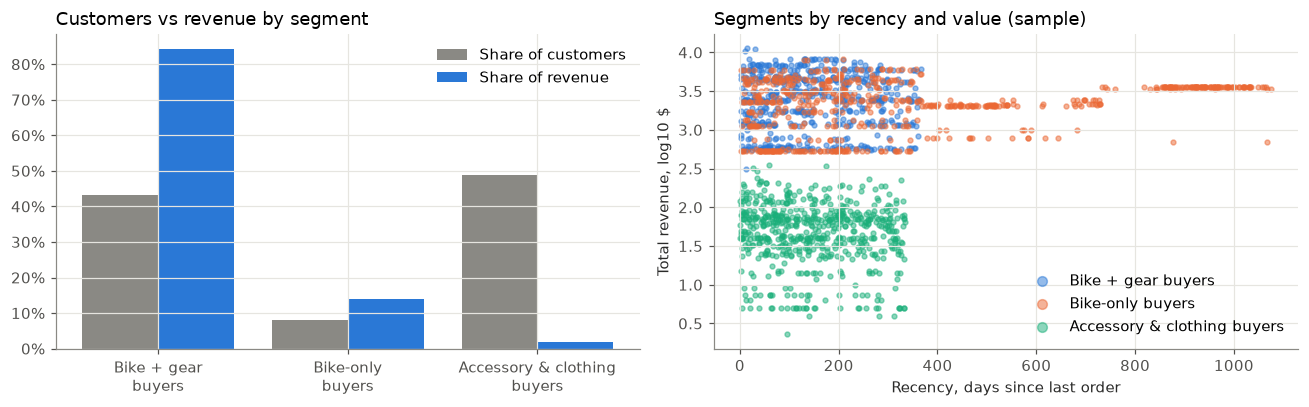

In [17]:
SEG_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
order = list(prof.index)
seg_label = dict(zip(prof.index, prof["segment"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
x = np.arange(len(order))
axes[0].bar(x - 0.2, prof["customer_share"], 0.4, color="#8a8984", label="Share of customers")
axes[0].bar(x + 0.2, prof["revenue_share"], 0.4, color="#2a78d6", label="Share of revenue")
axes[0].set_xticks(x, [seg_label[c].replace(" buyers", "\nbuyers") for c in order]); axes[0].legend()
axes[0].set_title("Customers vs revenue by segment", loc="left"); axes[0].yaxis.set_major_formatter("{x:.0%}")
for i, c in enumerate(order):
    s = feat[labels == c]
    axes[1].scatter(s["recency_days"].sample(min(600, len(s)), random_state=SEED),
                    np.log10(s["total_revenue"].sample(min(600, len(s)), random_state=SEED)),
                    s=10, alpha=0.5, color=SEG_COLORS[i % len(SEG_COLORS)], label=seg_label[c])
axes[1].set_xlabel("Recency, days since last order"); axes[1].set_ylabel("Total revenue, log10 $")
axes[1].set_title("Segments by recency and value (sample)", loc="left"); axes[1].legend(markerscale=2)
fig.tight_layout()
save(fig, "segments.png")

### 2.5 Cross-check: do other algorithms find the same segments?

K-means assumes round clusters of similar size. If the segments are real structure in the data, algorithms with
different assumptions should find largely the same groups. Two checks on the same scaled features and the same k:

- **Gaussian mixture** (full covariance): allows elongated clusters of different sizes and spreads.
- **Agglomerative clustering, Ward linkage**: builds clusters bottom-up instead of from centroids. It needs
  pairwise distances, so it runs on a random sample of 5,000 customers.

Agreement is measured with the adjusted Rand index (ARI: 1 = identical grouping, 0 = chance).

In [18]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

Z_all = final[:-1].transform(X)
gmm = GaussianMixture(n_components=K, covariance_type="full", n_init=3, random_state=SEED).fit(Z_all)
gmm_labels = gmm.predict(Z_all)

agg_idx = np.random.default_rng(SEED).choice(len(X), size=min(5000, len(X)), replace=False)
agg_labels = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(Z_all[agg_idx])

xcheck = pd.DataFrame([
    {"method": "Gaussian mixture (all customers)", "ARI vs K-means": adjusted_rand_score(labels, gmm_labels),
     "silhouette": silhouette_score(Z_all[sample_idx], gmm_labels[sample_idx])},
    {"method": "Agglomerative, Ward (5,000 sample)", "ARI vs K-means": adjusted_rand_score(labels[agg_idx], agg_labels),
     "silhouette": silhouette_score(Z_all[agg_idx], agg_labels)},
    {"method": "K-means (reference)", "ARI vs K-means": 1.0,
     "silhouette": silhouette_score(Z_all[sample_idx], labels[sample_idx])},
])
xcheck.to_csv(TAB / "cluster_method_crosscheck.csv", index=False)
display(xcheck.round(3))

# Where do the other methods put each K-means segment? Rows: K-means segment; columns: other method's cluster.
ct_gmm = pd.crosstab(pd.Series(labels).map(seg_label).rename("K-means segment"),
                     pd.Series(gmm_labels, name="Gaussian mixture cluster"), normalize="index")
ct_agg = pd.crosstab(pd.Series(labels[agg_idx]).map(seg_label).rename("K-means segment"),
                     pd.Series(agg_labels, name="Ward cluster"), normalize="index")
display(ct_gmm.style.format("{:.0%}").set_caption("Share of each K-means segment by Gaussian mixture cluster"))
display(ct_agg.style.format("{:.0%}").set_caption("Share of each K-means segment by Ward cluster (sample)"))

,method,ARI vs K-means,silhouette
0,Gaussian mixture (all customers),0.708,0.328
1,"Agglomerative, Ward (5,000 sample)",0.903,0.459
2,K-means (reference),1.000,0.436


Gaussian mixture cluster,0,1,2
K-means segment,,,
Accessory & clothing buyers,0%,82%,18%
Bike + gear buyers,99%,0%,1%
Bike-only buyers,100%,0%,0%


Ward cluster,0,1,2
K-means segment,,,
Accessory & clothing buyers,0%,100%,0%
Bike + gear buyers,99%,1%,0%
Bike-only buyers,61%,0%,39%


**What the cross-check shows**

- **The main split is robust.** All three methods separate customers who buy bikes from customers who only buy
  accessories and clothing: Ward puts 100% of the accessory and clothing buyers in one cluster, and the Gaussian
  mixture puts 99 to 100% of both bike segments together, away from them.
- **The split within bike buyers depends on the method.** Ward largely reproduces it (ARI 0.90 with K-means), but
  the Gaussian mixture merges bike + gear buyers and bike-only buyers into a single cluster (ARI 0.71), and splits
  the accessory buyers instead. So "buys bikes or not" is structure in the data; "bike + gear vs bike-only" is a
  weaker, method-dependent boundary.
- **Practical consequence:** the strategies in 2.6 still apply, because bike-only vs bike + gear can be assigned
  by a simple rule (number of categories bought) without any clustering. The clustering's real contribution is
  confirming that the dominant divide is product type, not spend level.

### 2.6 Segment names and strategies

Names were assigned **after** reading the profiles above, by a fixed rule on each segment's average bike share
and category count. Figures below are from this run.

| Segment | Who they are | Strategy |
|---|---|---|
| **Bike + gear buyers** (about 43% of customers, 84% of individual revenue) | Bought a bike **and** accessories or clothing; most likely to repeat (1.8 orders on average); recent | **Protect and deepen.** Loyalty tier with service and maintenance perks, early access to new models, trade-in credit toward the next bike. This is where retention spending pays back. |
| **Bike-only buyers** (about 8% of customers, 14% of revenue) | One category only (bikes), mostly one order. 72% first bought **before June 2013, when the online store sold almost nothing but bikes** (vs 57% of Bike + gear buyers), so many were never offered gear online. Least recent (median 238 days) | **Win back with the gear they could not buy at the time.** Helmets, clothing and maintenance kits matched to the bike they own, as a time-limited bundle. Reactivation email series; a service reminder at the bike's age. |
| **Accessory & clothing buyers** (about 49% of customers, 2% of revenue) | Never bought a bike online; median spend about $50; newest segment (most arrived with the mid-2013 catalog expansion) | **Convert to a first bike, cheaply.** Test-ride and financing offers, bike content triggered by gear purchases, free-shipping thresholds and bundles to lift basket size. Keep acquisition cost low; at $50 per customer, paid channels lose money. |

**Caveats.** k = 2 and k = 3 have nearly identical silhouette (0.434 vs 0.436); k = 3 was chosen because it is
stable (ARI 0.98 across seeds) and splits bike buyers by cross-category behavior, which a strategy can act on.
Dropping `total_revenue` leaves the segments unchanged (ARI 0.999), so the revenue/orders/AOV redundancy does not
drive them. Dropping the product-mix features changes them substantially (ARI 0.86): **what customers buy separates
them more than how much they spend.** Part of the segmentation reflects **catalog timing** (what was available
online when a customer arrived), not just preference.

### 2.7 Reseller (store) customers, profiled separately

In [19]:
stores = sql(f'''
SELECT o.customer_id, s.name AS store, o.territory,
       SUM(o.revenue) AS revenue, COUNT(*) AS orders, AVG(o.revenue) AS aov,
       DATE_DIFF('day', MAX(o.order_date), DATE '{END}') AS recency_days
FROM fct_orders o JOIN store s ON o.store_id = s.business_entity_id
WHERE o.channel = 'Store (reseller)' AND o.order_date < '{END}'
GROUP BY 1, 2, 3
''')
stores["value_tier"] = pd.qcut(stores["revenue"].rank(method="first"), 4, labels=["Q4 (lowest)", "Q3", "Q2", "Q1 (top)"])
stores["status"] = np.where(stores["recency_days"] <= 120, "Active (ordered in last 120 days)", "Lapsed (>120 days)")
st = stores.pivot_table(index="value_tier", columns="status", values="revenue", aggfunc=["count", "sum"], observed=False)
display(st.style.format("{:,.0f}"))
top_share = stores.nlargest(int(len(stores) * 0.2), "revenue")["revenue"].sum() / stores["revenue"].sum()
lapsed_q1 = stores[(stores.value_tier == "Q1 (top)") & (stores.status.str.startswith("Lapsed"))]
print(f"{len(stores)} stores. Top 20% of stores = {top_share:.0%} of reseller revenue. "
      f"Top-quartile stores that have lapsed: {len(lapsed_q1)}, worth ${lapsed_q1.revenue.sum():,.0f} historically.")
stores.to_csv(TAB / "store_profiles.csv", index=False)

635 stores. Top 20% of stores = 67% of reseller revenue. Top-quartile stores that have lapsed: 24, worth $7,463,118 historically.


## 3. Monthly forecasting for top-selling products

**Target**: monthly **units** sold per product (both channels combined). Revenue is reported alongside using the
product's recent average selling price. Units are what inventory and production plan against; revenue mixes in
price and discount changes.

### 3.1 Complete product-month dataset (SQL)

Every product gets a row for every month from its first sale to May 2014. Months with no sales are filled with
**0** (genuine zero demand, because the product was already on sale). Months before a product's first sale are
**not** filled, because the product did not exist yet; filling them would invent demand history.

In [20]:
pm = sql(f'''
WITH months AS (
  SELECT CAST(m AS DATE) AS month FROM generate_series(DATE '2011-05-01', DATE '2014-05-01', INTERVAL 1 MONTH) g(m)),
sales AS (
  SELECT product_id, order_month AS month, SUM(order_qty) AS units, SUM(revenue) AS revenue
  FROM fct_sales_lines WHERE order_date < '{END}' GROUP BY 1, 2),
first_sale AS (SELECT product_id, MIN(month) AS first_month FROM sales GROUP BY 1)
SELECT f.product_id, dp.product, dp.category, m.month,
       COALESCE(s.units, 0) AS units, COALESCE(s.revenue, 0) AS revenue,
       (s.units IS NULL) AS zero_month
FROM first_sale f
JOIN months m      ON m.month >= f.first_month
JOIN dim_product dp ON dp.product_id = f.product_id
LEFT JOIN sales s  ON s.product_id = f.product_id AND s.month = m.month
ORDER BY 1, 4
''')
pm["month"] = pd.to_datetime(pm["month"])
print(f"{pm.product_id.nunique()} products, {len(pm):,} product-months, "
      f"{pm.zero_month.mean():.1%} of product-months are genuine zero-demand months")

266 products, 5,724 product-months, 33.3% of product-months are genuine zero-demand months


### 3.2 Selecting the top products without peeking at the test period

The backtest holds out the last 6 months (Dec 2013 to May 2014). Products are ranked on units sold **before**
that window only, and must have sales in at least 90% of training months, so the forecast is about demand and not
about launch ramps (many top sellers by total units only launched in May 2013).

In [21]:
TEST_START = pd.Timestamp("2013-12-01")
train_pm = pm[pm.month < TEST_START]
n_train_months = train_pm.month.nunique()
rank = (train_pm.groupby(["product_id", "product", "category"])
        .agg(train_units=("units", "sum"), months_listed=("month", "nunique"),
             months_with_sales=("zero_month", lambda z: (~z).sum()))
        .reset_index())
rank["coverage"] = rank["months_with_sales"] / n_train_months
TOP = (rank[rank.coverage >= 0.9].sort_values("train_units", ascending=False).head(5))
display(TOP)
top_ids = TOP.product_id.tolist()
series = (pm[pm.product_id.isin(top_ids)].pivot(index="month", columns="product_id", values="units")
          .reindex(columns=top_ids).asfreq("MS").fillna(0))
names = dict(zip(TOP.product_id, TOP["product"]))
series.rename(columns=names).tail(6)

,product_id,product,category,train_units,months_listed,months_with_sales,coverage
5,712,AWC Logo Cap,Clothing,6060.0,31,28,0.903226
8,715,"Long-Sleeve Logo Jersey, L",Clothing,5401.0,31,28,0.903226
4,711,"Sport-100 Helmet, Blue",Accessories,4707.0,31,28,0.903226
1,708,"Sport-100 Helmet, Black",Accessories,4553.0,31,28,0.903226
0,707,"Sport-100 Helmet, Red",Accessories,4291.0,31,28,0.903226


product_id,AWC Logo Cap,"Long-Sleeve Logo Jersey, L","Sport-100 Helmet, Blue","Sport-100 Helmet, Black","Sport-100 Helmet, Red"
month,,,,,
2013-12-01,301.0,166.0,260.0,263.0,258.0
2014-01-01,365.0,184.0,278.0,291.0,271.0
2014-02-01,180.0,39.0,181.0,154.0,182.0
2014-03-01,663.0,464.0,570.0,569.0,556.0
2014-04-01,193.0,34.0,222.0,191.0,241.0
2014-05-01,456.0,285.0,431.0,420.0,390.0


### 3.3 Trend and seasonality

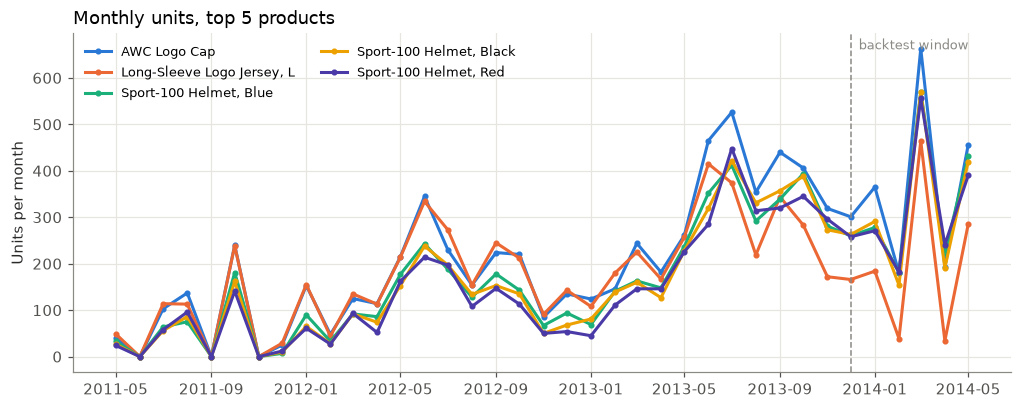

STL on total units of the top 5: trend strength 0.87, seasonal strength 0.79 (0 = none, 1 = dominant)


,lag-12 autocorrelation
AWC Logo Cap,0.62
"Long-Sleeve Logo Jersey, L",0.45
"Sport-100 Helmet, Blue",0.63
"Sport-100 Helmet, Black",0.64
"Sport-100 Helmet, Red",0.61


In [22]:
PROD_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#4a3aa7"]
fig, ax = plt.subplots(figsize=(11, 4))
for i, pid in enumerate(top_ids):
    ax.plot(series.index, series[pid], "-o", ms=3, color=PROD_COLORS[i], label=names[pid])
ax.axvline(TEST_START, color=MUTED, linestyle="--", linewidth=1)
ax.text(TEST_START, ax.get_ylim()[1] * 0.95, "  backtest window", color=MUTED, fontsize=8.5)
ax.set_ylabel("Units per month"); ax.set_title("Monthly units, top 5 products", loc="left")
ax.legend(fontsize=8.5, ncol=2)
save(fig, "top_products_units.png")

total = series.sum(axis=1)
stl = STL(total, period=12, robust=True).fit()
strength_trend = max(0, 1 - np.var(stl.resid) / np.var(stl.trend + stl.resid))
strength_season = max(0, 1 - np.var(stl.resid) / np.var(stl.seasonal + stl.resid))
acf12 = {names[p]: series[p].autocorr(lag=12) for p in top_ids}
print(f"STL on total units of the top 5: trend strength {strength_trend:.2f}, seasonal strength {strength_season:.2f} "
      "(0 = none, 1 = dominant)")
pd.Series(acf12, name="lag-12 autocorrelation").round(2).to_frame()

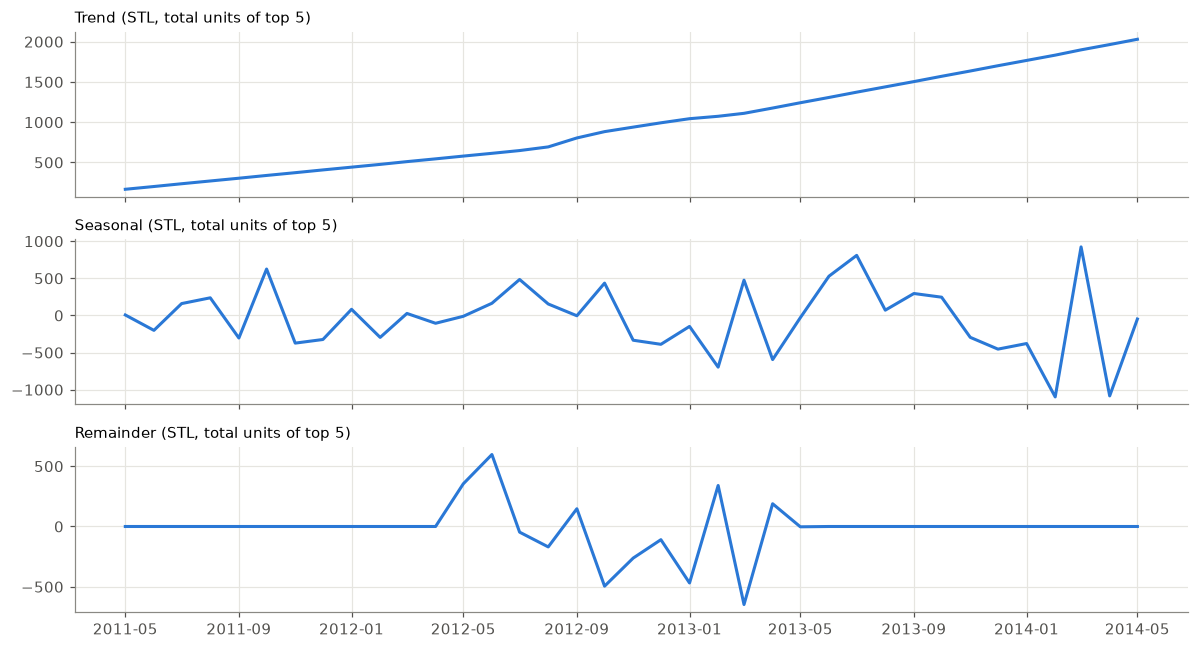

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for ax, comp, title in [(axes[0], stl.trend, "Trend"), (axes[1], stl.seasonal, "Seasonal"), (axes[2], stl.resid, "Remainder")]:
    ax.plot(total.index, comp, color="#2a78d6")
    ax.set_title(f"{title} (STL, total units of top 5)", loc="left", fontsize=10)
fig.tight_layout()
save(fig, "stl_decomposition.png")

### 3.4 Growth and decline

Year-over-year change per product, two ways, because the data starts in May 2011 and stops in May 2014:
**full calendar years** 2012 vs 2013, and the **same five months** (January to May) of 2013 vs 2014.

In [24]:
g = pm[pm.product_id.isin(top_ids)].assign(year=lambda d: d.month.dt.year, mon=lambda d: d.month.dt.month)
full = g[g.year.isin([2012, 2013])].pivot_table(index="product", columns="year", values="units", aggfunc="sum")
ytd = g[g.mon.le(5) & g.year.isin([2013, 2014])].pivot_table(index="product", columns="year", values="units", aggfunc="sum")
rev = g[g.year.isin([2012, 2013])].pivot_table(index="product", columns="year", values="revenue", aggfunc="sum")
growth = pd.DataFrame({
    "units_2012": full[2012], "units_2013": full[2013], "yoy_units_2013": full[2013] / full[2012] - 1,
    "revenue_2013": rev[2013], "yoy_revenue_2013": rev[2013] / rev[2012] - 1,
    "units_jan_may_2013": ytd[2013], "units_jan_may_2014": ytd[2014],
    "yoy_units_jan_may_2014": ytd[2014] / ytd[2013] - 1,
}).loc[[names[p] for p in top_ids]]
growth.to_csv(TAB / "top_products_growth.csv")
growth.style.format({c: "{:+.0%}" for c in growth if c.startswith("yoy")} |
                    {c: "{:,.0f}" for c in growth if c.startswith("units")} |
                    {c: "${:,.0f}" for c in growth if c.startswith("revenue")})

,units_2012,units_2013,yoy_units_2013,revenue_2013,yoy_revenue_2013,units_jan_may_2013,units_jan_may_2014,yoy_units_jan_may_2014
product,,,,,,,,
AWC Logo Cap,"2,048","3,768",+84%,"$23,583",+127%,957,"1,857",+94%
"Long-Sleeve Logo Jersey, L","2,113","2,910",+38%,"$89,058",+50%,937,"1,006",+7%
"Sport-100 Helmet, Blue","1,519","3,088",+103%,"$76,243",+158%,758,"1,682",+122%
"Sport-100 Helmet, Black","1,387","3,088",+123%,"$76,704",+184%,735,"1,625",+121%
"Sport-100 Helmet, Red","1,278","2,940",+130%,"$74,566",+200%,674,"1,640",+143%


**What the growth table shows**

- **All five top products grew; none declined.** Units roughly doubled from 2012 to 2013 (+38% to +130%), and the
  growth continued into 2014 for the cap and the three helmets (+94% to +143% for January to May).
- **The long-sleeve jersey is flattening:** +38% in 2013, but only +7% for January to May 2014. It is the one
  product whose growth is clearly slowing.
- **Revenue grew faster than units** (for example the cap: +84% units, +127% revenue), so realized revenue per
  unit rose. The 4% list price increase in May 2013 (3.8) explains only part of it; a smaller share of
  volume-discounted reseller units is a likely contributor, but this table alone does not establish that.
- Most of the growth arrives after mid-2013, matching the change points in 3.5: the jump comes with the online
  catalog expansion, not as a steady trend.

### 3.5 Change points

Optimal segmentation of each series into constant-mean pieces (dynamic programming, exact), with a penalty per
extra break. The penalty is varied to show which breaks are **robust** (found at every setting) and which are
artifacts of one setting. Breaks are candidates to investigate, not proven causes.

In [25]:
def segment_mean_shifts(y, penalty, min_size=3):
    # Exact optimal partition minimizing within-segment squared error + penalty * number of segments.
    y = np.asarray(y, float); n = len(y)
    cs, cs2 = np.r_[0, np.cumsum(y)], np.r_[0, np.cumsum(y ** 2)]
    cost = lambda i, j: (cs2[j] - cs2[i]) - (cs[j] - cs[i]) ** 2 / (j - i)
    best, prev = np.full(n + 1, np.inf), np.zeros(n + 1, int)
    best[0] = -penalty
    for j in range(min_size, n + 1):
        for i in range(0, j - min_size + 1):
            if i != 0 and i < min_size:
                continue
            c = best[i] + cost(i, j) + penalty
            if c < best[j]:
                best[j], prev[j] = c, i
    bks, j = [], n
    while j > 0:
        j = prev[j]
        if j > 0:
            bks.append(j)
    return sorted(bks)

cp_rows = []
for pid in top_ids:
    y = series[pid].values
    sigma2 = np.median(np.abs(np.diff(y))) ** 2 / 0.4549   # robust noise variance from differences
    for mult in [2, 4, 8]:                                    # BIC-like penalty: mult * sigma^2 * log(n)
        bks = segment_mean_shifts(y, penalty=mult * sigma2 * np.log(len(y)))
        cp_rows.append({"product": names[pid], "penalty_mult": mult,
                        "breaks": ", ".join(series.index[b].strftime("%Y-%m") for b in bks) or "none"})
cps = pd.DataFrame(cp_rows).pivot(index="product", columns="penalty_mult", values="breaks")
cps.columns = [f"penalty x{c}" for c in cps.columns]
cps.to_csv(TAB / "change_points.csv")
cps

,penalty x2,penalty x4,penalty x8
product,,,
AWC Logo Cap,2013-06,2013-06,2013-06
"Long-Sleeve Logo Jersey, L",2012-05,none,none
"Sport-100 Helmet, Black",2013-05,2013-05,2013-05
"Sport-100 Helmet, Blue",2013-05,2013-05,2013-05
"Sport-100 Helmet, Red",2013-05,2013-05,2013-05


### 3.6 Models and rolling-origin backtest

Candidates, from simplest to most complex:

| Model | Idea |
|---|---|
| Naive | next month = this month |
| Seasonal naive | next month = same month last year |
| Moving average (3) | next month = mean of last 3 months |
| ETS (A,N,N) | simple exponential smoothing, additive errors |
| ETS (A,Ad,N) | exponential smoothing with a damped additive trend |
| ETS (A,N,N) post-break | simple exponential smoothing fitted only on data after July 2013 (the catalog-expansion break) |

No seasonal ETS: with about 30 months of training data there are not enough full years to estimate 12 seasonal
terms reliably, and section 3.3 shows weak seasonality.

**Backtest**: expanding window, forecast origins at the end of Nov 2013, Dec 2013, Jan 2014 and Feb 2014, horizon
1 to 3 months, so every forecast target falls in Dec 2013 to May 2014. Error metrics: **MAE** (units) and
**WAPE** (sum of absolute errors / sum of actuals, comparable across products of different size).

In [26]:
import warnings
warnings.filterwarnings("ignore")
BREAK = pd.Timestamp("2013-07-01")
H = 3

def fc_naive(y, h):        return np.repeat(y.iloc[-1], h)
def fc_snaive(y, h):       return np.array([y.iloc[-12 + (i % 12)] for i in range(h)]) if len(y) >= 12 else fc_naive(y, h)
def fc_ma3(y, h):          return np.repeat(y.iloc[-3:].mean(), h)
def _ets(y, h, trend=None, damped=False):
    m = ETSModel(y.astype(float), error="add", trend=trend, damped_trend=damped).fit(disp=False)
    return np.clip(m.forecast(h).values, 0, None)
def fc_ets(y, h):          return _ets(y, h)
def fc_ets_damped(y, h):   return _ets(y, h, trend="add", damped=True)
def fc_ets_post(y, h):     return _ets(y[y.index >= BREAK], h) if (y.index >= BREAK).sum() >= 4 else _ets(y, h)

MODELS = {"Naive": fc_naive, "Seasonal naive": fc_snaive, "Moving avg (3)": fc_ma3,
          "ETS (A,N,N)": fc_ets, "ETS (A,Ad,N)": fc_ets_damped, "ETS (A,N,N) post-break": fc_ets_post}
ORIGINS = pd.date_range("2013-11-01", "2014-02-01", freq="MS")   # last observed month at each origin

bt = []
for pid in top_ids:
    y_all = series[pid]
    for origin in ORIGINS:
        y_tr = y_all[y_all.index <= origin]
        y_te = y_all[(y_all.index > origin)].iloc[:H]
        for name, f in MODELS.items():
            pred = f(y_tr, H)
            for h, (t, actual) in enumerate(y_te.items(), start=1):
                bt.append({"product": names[pid], "model": name, "origin": origin, "h": h, "month": t,
                           "actual": actual, "forecast": pred[h - 1]})
bt = pd.DataFrame(bt)
bt["abs_err"] = (bt.actual - bt.forecast).abs()
bt.to_csv(TAB / "backtest_forecasts.csv", index=False)

def wape(g): return g.abs_err.sum() / g.actual.sum()
by_model = bt.groupby("model").apply(lambda g: pd.Series({"MAE": g.abs_err.mean(), "WAPE": wape(g)}),
                                      include_groups=False).sort_values("WAPE")
by_prod = bt.groupby(["product", "model"]).apply(wape, include_groups=False).unstack("model")
by_prod = by_prod[by_model.index]
display(by_model.style.format({"MAE": "{:,.1f}", "WAPE": "{:.1%}"}))
by_prod.style.format("{:.1%}").highlight_min(axis=1, color="#d6e6f9")

,MAE,WAPE
model,,
"ETS (A,N,N)",150.5,49.0%
Naive,151.8,49.4%
Moving avg (3),152.2,49.5%
"ETS (A,Ad,N)",158.3,51.5%
"ETS (A,N,N) post-break",162.4,52.8%
Seasonal naive,179.3,58.3%


model,"ETS (A,N,N)",Naive,Moving avg (3),"ETS (A,Ad,N)","ETS (A,N,N) post-break",Seasonal naive
product,,,,,,
AWC Logo Cap,47.1%,49.5%,47.4%,48.7%,50.2%,50.5%
"Long-Sleeve Logo Jersey, L",83.6%,77.0%,83.8%,93.3%,89.7%,67.2%
"Sport-100 Helmet, Black",46.0%,47.8%,47.3%,47.3%,49.5%,57.8%
"Sport-100 Helmet, Blue",41.6%,42.0%,43.0%,43.4%,45.5%,57.5%
"Sport-100 Helmet, Red",40.2%,41.4%,39.5%,41.3%,43.8%,63.1%


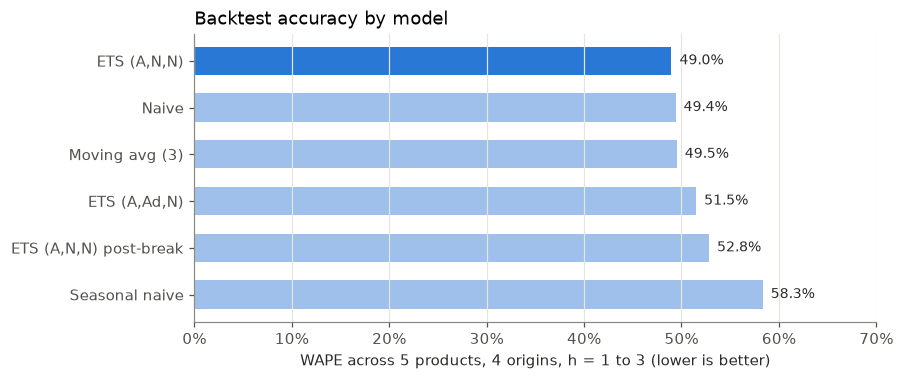

In [27]:
fig, ax = plt.subplots(figsize=(8, 3.4))
d = by_model.sort_values("WAPE", ascending=False)
ax.barh(d.index, d["WAPE"], color=["#2a78d6" if i == len(d) - 1 else "#9fc0ea" for i in range(len(d))], height=0.6)
for y, v in enumerate(d["WAPE"]):
    ax.text(v, y, f"  {v:.1%}", va="center", fontsize=9, color=INK)
ax.set_xlim(0, d["WAPE"].max() * 1.2); ax.xaxis.set_major_formatter("{x:.0%}")
ax.set_xlabel("WAPE across 5 products, 4 origins, h = 1 to 3 (lower is better)")
ax.set_title("Backtest accuracy by model", loc="left"); ax.grid(axis="y", visible=False)
save(fig, "backtest_wape.png")

### 3.7 Forecast for June to August 2014, with prediction intervals

Each product uses the model with the lowest backtest WAPE **for that product**, refitted on all data through May
2014. Intervals are 80% and 95% prediction intervals. For ETS models they come from the fitted model; for naive
and moving-average models they come from the empirical spread of that model's backtest errors at each horizon.

In [28]:
FUT = pd.date_range("2014-06-01", periods=H, freq="MS")
best_model = by_prod.idxmin(axis=1)
z80, z95 = 1.2816, 1.96

fc_rows = []
for pid in top_ids:
    name = names[pid]; mname = best_model[name]; y = series[pid]
    # average realized price over the last 6 months, to translate units into revenue
    recent = pm[(pm.product_id == pid) & (pm.month >= "2013-12-01")]
    price = recent.revenue.sum() / max(recent.units.sum(), 1)
    if mname.startswith("ETS"):
        y_fit = y[y.index >= BREAK] if "post-break" in mname else y
        trend, damped = ("add", True) if "Ad" in mname else (None, False)
        res = ETSModel(y_fit.astype(float), error="add", trend=trend, damped_trend=damped).fit(disp=False)
        sf = res.get_prediction(start=len(y_fit), end=len(y_fit) + H - 1).summary_frame(alpha=0.05)
        sf80 = res.get_prediction(start=len(y_fit), end=len(y_fit) + H - 1).summary_frame(alpha=0.20)
        point = sf["mean"].values
        lo95, hi95, lo80, hi80 = sf["pi_lower"].values, sf["pi_upper"].values, sf80["pi_lower"].values, sf80["pi_upper"].values
    else:
        point = MODELS[mname](y, H)
        err = bt[(bt["product"] == name) & (bt.model == mname)]
        sd = err.assign(e=err.actual - err.forecast).groupby("h")["e"].std().reindex(range(1, H + 1)).ffill().values
        lo95, hi95, lo80, hi80 = point - z95 * sd, point + z95 * sd, point - z80 * sd, point + z80 * sd
    for i, m in enumerate(FUT):
        fc_rows.append({"product": name, "model": mname, "month": m.strftime("%Y-%m"),
                        "units": max(point[i], 0), "lo80": max(lo80[i], 0), "hi80": hi80[i],
                        "lo95": max(lo95[i], 0), "hi95": hi95[i], "est_revenue": max(point[i], 0) * price})
fc = pd.DataFrame(fc_rows)
fc.to_csv(TAB / "forecast_jun_aug_2014.csv", index=False)
fc.style.format({"units": "{:,.0f}", "lo80": "{:,.0f}", "hi80": "{:,.0f}", "lo95": "{:,.0f}", "hi95": "{:,.0f}",
                 "est_revenue": "${:,.0f}"})

,product,model,month,units,lo80,hi80,lo95,hi95,est_revenue
0,AWC Logo Cap,"ETS (A,N,N)",2014-06,378,222,534,140,616,"$2,781"
1,AWC Logo Cap,"ETS (A,N,N)",2014-07,378,216,541,130,627,"$2,781"
2,AWC Logo Cap,"ETS (A,N,N)",2014-08,378,209,547,119,637,"$2,781"
3,"Long-Sleeve Logo Jersey, L",Seasonal naive,2014-06,415,214,616,108,722,"$13,968"
4,"Long-Sleeve Logo Jersey, L",Seasonal naive,2014-07,374,140,608,16,732,"$12,588"
5,"Long-Sleeve Logo Jersey, L",Seasonal naive,2014-08,219,0,448,0,569,"$7,371"
6,"Sport-100 Helmet, Blue","ETS (A,N,N)",2014-06,358,237,479,173,543,"$10,463"
7,"Sport-100 Helmet, Blue","ETS (A,N,N)",2014-07,358,229,487,161,555,"$10,463"
8,"Sport-100 Helmet, Blue","ETS (A,N,N)",2014-08,358,221,494,149,567,"$10,463"
9,"Sport-100 Helmet, Black","ETS (A,N,N)",2014-06,345,221,469,156,535,"$10,003"


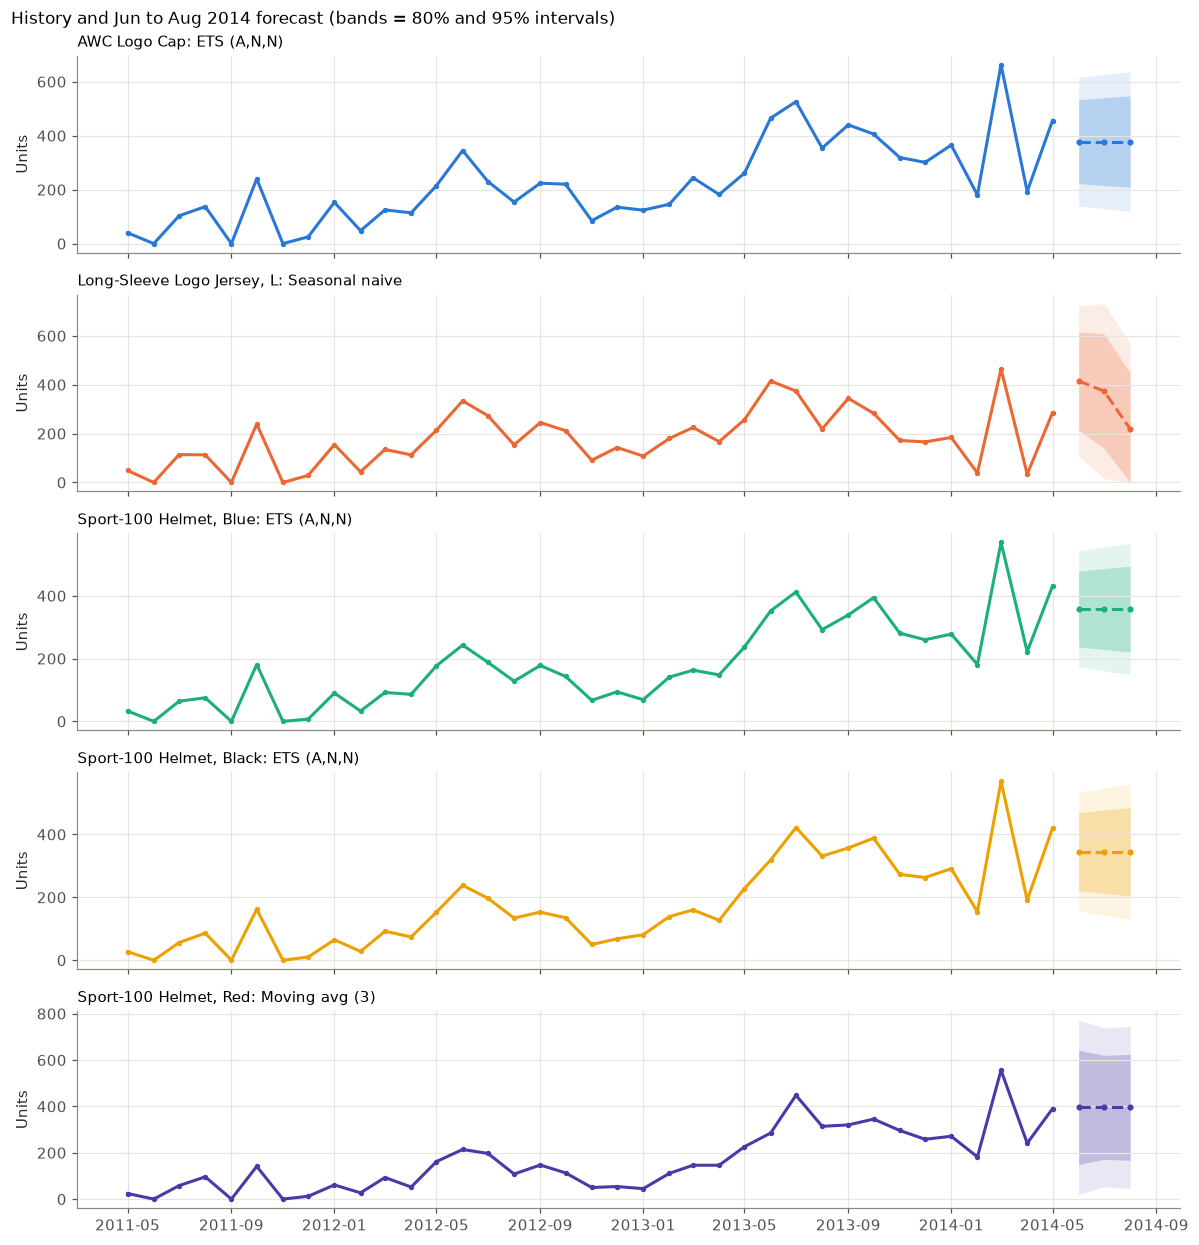

In [29]:
fig, axes = plt.subplots(len(top_ids), 1, figsize=(11, 2.3 * len(top_ids)), sharex=True)
for ax, pid, c in zip(axes, top_ids, PROD_COLORS):
    name = names[pid]; f = fc[fc["product"] == name]; fm = pd.to_datetime(f["month"])
    ax.plot(series.index, series[pid], "-o", ms=2.5, color=c)
    ax.fill_between(fm, f["lo95"], f["hi95"], color=c, alpha=0.12, linewidth=0)
    ax.fill_between(fm, f["lo80"], f["hi80"], color=c, alpha=0.25, linewidth=0)
    ax.plot(fm, f["units"], "--o", ms=3, color=c)
    ax.set_title(f"{name}: {f['model'].iloc[0]}", loc="left", fontsize=9.5)
    ax.set_ylabel("Units")
fig.suptitle("History and Jun to Aug 2014 forecast (bands = 80% and 95% intervals)", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
save(fig, "forecasts.png")

### 3.8 Factors beyond the sales data

In [30]:
promo = sql(f'''
SELECT product, SUM(order_qty) AS units,
       SUM(CASE WHEN unit_price_discount > 0 THEN order_qty ELSE 0 END) * 1.0 / SUM(order_qty) AS discounted_unit_share,
       COUNT(DISTINCT special_offer_id) AS offers_used
FROM fct_sales_lines WHERE product_id IN ({",".join(map(str, top_ids))}) AND order_date < '{END}'
GROUP BY 1 ORDER BY units DESC
''')
prices = sql(f'''
SELECT dp.product, h.start_date, h.end_date, h.list_price
FROM product_list_price_history h JOIN dim_product dp USING (product_id)
WHERE h.product_id IN ({",".join(map(str, top_ids))}) ORDER BY 1, 2
''')
display(promo.style.format({"units": "{:,.0f}", "discounted_unit_share": "{:.1%}"}))
prices

,product,units,discounted_unit_share,offers_used
0,AWC Logo Cap,"8,218",19.7%,4
1,"Sport-100 Helmet, Blue","6,649",18.6%,5
2,"Long-Sleeve Logo Jersey, L","6,573",24.0%,4
3,"Sport-100 Helmet, Black","6,441",18.1%,5
4,"Sport-100 Helmet, Red","6,189",15.5%,5


,product,start_date,end_date,list_price
0,AWC Logo Cap,2011-05-31,2012-05-29,8.6442
1,AWC Logo Cap,2012-05-30,2013-05-29,8.6442
2,AWC Logo Cap,2013-05-30,NaT,8.9900
3,"Long-Sleeve Logo Jersey, L",2011-05-31,2012-05-29,48.0673
4,"Long-Sleeve Logo Jersey, L",2012-05-30,2013-05-29,48.0673
5,"Long-Sleeve Logo Jersey, L",2013-05-30,NaT,49.9900
6,"Sport-100 Helmet, Black",2011-05-31,2012-05-29,33.6442
7,"Sport-100 Helmet, Black",2012-05-30,2013-05-29,33.6442
8,"Sport-100 Helmet, Black",2013-05-30,NaT,34.9900
9,"Sport-100 Helmet, Blue",2011-05-31,2012-05-29,33.6442


**Accuracy.** Backtest WAPE is about 40% to 50% for every model. ETS (A,N,N), naive and the 3-month moving
average are effectively tied (49.0%, 49.4%, 49.5%). **No model meaningfully beats the naive baseline**, so the
point forecasts should be read as a level estimate (about 350 to 400 units per product per month) with wide
intervals, not as month-by-month predictions. Seasonal naive is worst overall (58.3%) because "same month last
year" comes from **before** the mid-2013 break, at a much lower level. It wins only for the long-sleeve jersey.

**What drives the error and the history, beyond what the models see**

- **Catalog expansion (robust change point).** Four of the five products break in **May to June 2013** at every
  penalty setting, matching the date accessories and clothing went on sale online (2013-05-30, section 1.4).
- **Price changes.** List prices rose about 4% on the same date (helmets $33.64 to $34.99, cap $8.64 to $8.99),
  yet volume rose, so the break is driven by the channel launch, not price. The two effects cannot be fully
  separated, because they happened on the same day.
- **Promotions.** 15% to 24% of these products' units were sold at a discount, across 4 to 5 special offers.
  The models do not see planned promotions; a promotion in the forecast window would push actuals above the
  forecast.
- **Reseller order cadence.** Months with no reseller batch (Feb and Apr 2014) drop sharply and the next month
  spikes. This timing, not consumer demand, is the largest source of forecast error.
- **External events** not in the data: cycling-season weather, consumer spending, competitor pricing, new-model
  launches. Any of these would need external data to model.

**Next step that would most improve accuracy**: forecast the **online** and **reseller** channels separately
(online is smooth and trending; reseller is lumpy and better forecast quarterly), then add them together.

## 4. Summary of findings

**1. Sales exploration**

- Bikes are **86%** of revenue ($94.7M of $109.8M, May 2011 to May 2014); components 11%, clothing 2%, accessories
  1%. Road bikes alone are $43.9M. Accessories and clothing sell many units but little revenue.
- Order lines reconcile exactly to order subtotals, and TotalDue = subtotal + tax + freight on all 31,465 orders.
- Territory AOV rankings are almost entirely **channel mix** (r = 0.99 with store-order share). Within channels:
  resellers in the Southwest and France place the largest orders; online customers in Australia and Europe spend the
  most per order, and North American online customers buy mostly low-priced accessories.
- July 2013 is a **structural break**: accessories and clothing launched online, online orders tripled, and
  online AOV fell. June 2014 is a truncated extract and was excluded.

**2. Customer segments (individual customers; resellers profiled separately)**

- Three segments, cross-checked with a Gaussian mixture and Ward clustering: the **bike vs non-bike** split is
  found by all three methods; the split within bike buyers depends on the method. Segments: **Bike + gear buyers** (43% of customers, 84% of revenue), **Bike-only buyers** (8%, 14%;
  many arrived before gear was sold online), **Accessory & clothing buyers** (49%, 2%). Strategies: protect and
  deepen, win back with gear bundles, convert to a first bike cheaply.
- Resellers: the top 20% of stores generate 67% of reseller revenue. **24 top-quartile stores have not ordered in
  over 120 days**, worth $7.5M historically. They are the clearest account-management priority in the data.

**3. Product forecasts**

- All five top products grew from 2012 to 2013 (+38% to +130% in units). The helmets and the cap kept growing in
  2014 (+94% to +143%, January to May); the long-sleeve jersey slowed to +7%.
- Top 5 products by pre-test units: AWC Logo Cap, Long-Sleeve Logo Jersey (L), and the Sport-100 Helmet in blue,
  black and red.
- Robust change point in May to June 2013 for 4 of 5 products (online catalog expansion, with a concurrent 4% list
  price increase).
- No model beats naive by a meaningful margin (WAPE about 49%). The Jun to Aug 2014 forecasts are about 345 to 415
  units per product per month with wide intervals; reseller batch timing is the main source of error.